# CCT College Dublin
## Higher Diploma in Science in Data Analytics for Business

---

| | |
|---|---|
| **Student Name** | Gleiciane Rocha |
| **Module(s)** | Data Preparation / Statistical Techniques for DA / Machine Learning |
| **Assessment** | Integrated CA2 |
| **Dataset** | Irish Coastal Fisheries Performance Data |
| **Lecturer(s)** | David McQuaid / Sam Weiss / Muhammad Iqbal |
| **Submission Date** | 29th May 2026 |

---

## Project Overview

# Integrated CA2 — Fisheries Performance Analysis

This notebook contains the full analysis of a fisheries performance dataset collected across different Irish coastal counties. The dataset includes economic, environmental, operational, and sustainability-related indicators connected to the Irish fishing industry.

The main aim of this project is to explore the factors that influence fisheries performance, analyse export demand levels, and predict annual fisheries revenue using data analytics, statistics, and machine learning techniques.

The analysis is organised into three main sections:

- **Part 1 — Data Preparation:** Dataset characterisation, data cleaning, exploratory data analysis (EDA), encoding, scaling, feature engineering, and dimensionality reduction using PCA and LDA.

- **Part 2 — Statistical Techniques for Data Analytics:** Descriptive statistics, probability distributions, confidence intervals, hypothesis testing, correlation analysis, and linear regression.

- **Part 3 — Machine Learning:** Supervised and unsupervised learning, feature selection, hyperparameter tuning, cross-validation, and model comparison.

---

# Part 1 — Data Preparation

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_excel("Fisheries_CA2_Dataset (1).xlsx")

In [9]:
df.head()

,County,Avg_Fisher_Income_EUR,Fuel_Cost_Index,Port_Accessibility_Score,Fish_Stock_Index,Water_Quality_Score,Weather_Risk_Index,Illegal_Fishing_Rate_%,Aquaculture_Investment_EUR,Export_Demand_Level,Vessel_Type,Sustainability_Score,Predicted_Annual_Revenue_EUR
0,Waterford,81077.05,91.19,6.95,5.10,7.10,1.23,4.12,108112.88,High,Longliner,99.44,201495.28
1,Clare,76078.84,99.09,7.51,8.20,6.16,5.38,4.06,112746.74,Average,Trawler,115.02,202484.46
2,Cork,50576.94,91.93,7.59,3.82,4.04,4.71,3.07,132088.49,Low,Longliner,61.75,107997.00
3,Dublin,73236.59,109.53,6.29,7.02,7.60,5.99,5.56,109732.87,Average,Small Boat,115.48,188797.98
4,Dublin,69185.63,109.94,5.41,5.27,8.59,5.38,5.72,91268.62,Average,NaN,110.90,147138.23


In [10]:
df.shape

(2080, 13)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   County                        2059 non-null   object 
 1   Avg_Fisher_Income_EUR         2059 non-null   float64
 2   Fuel_Cost_Index               2059 non-null   float64
 3   Port_Accessibility_Score      2059 non-null   float64
 4   Fish_Stock_Index              2059 non-null   float64
 5   Water_Quality_Score           2059 non-null   float64
 6   Weather_Risk_Index            2059 non-null   float64
 7   Illegal_Fishing_Rate_%        2059 non-null   float64
 8   Aquaculture_Investment_EUR    2059 non-null   float64
 9   Export_Demand_Level           2059 non-null   object 
 10  Vessel_Type                   2059 non-null   object 
 11  Sustainability_Score          2059 non-null   float64
 12  Predicted_Annual_Revenue_EUR  2059 non-null   float64
dtypes: 

In [12]:
df.describe()

,Avg_Fisher_Income_EUR,Fuel_Cost_Index,Port_Accessibility_Score,Fish_Stock_Index,Water_Quality_Score,Weather_Risk_Index,Illegal_Fishing_Rate_%,Aquaculture_Investment_EUR,Sustainability_Score,Predicted_Annual_Revenue_EUR
count,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000
mean,72511.124876,100.088698,5.969354,5.955352,7.006960,4.114594,4.914230,109863.973458,103.040413,174679.905537
std,11845.548793,14.895004,1.980090,1.943586,1.457452,1.896673,2.002769,22225.645739,22.356924,43489.897248
min,35298.260000,52.680000,1.000000,1.000000,2.100000,1.000000,0.000000,38247.500000,25.490000,28148.810000
25%,64806.695000,90.280000,4.620000,4.640000,6.020000,2.695000,3.565000,95427.780000,88.230000,145903.220000
50%,72646.920000,100.280000,6.000000,5.940000,7.030000,4.060000,4.850000,110054.900000,103.500000,176154.600000
75%,80310.940000,109.885000,7.340000,7.260000,8.000000,5.430000,6.305000,125296.360000,118.050000,204900.420000
max,107127.470000,145.030000,10.000000,10.000000,10.000000,10.000000,11.790000,170958.000000,172.740000,303843.800000


## Dataset Characterisation

In [13]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 2080
Number of columns: 13


In [14]:
df.columns

Index(['County', 'Avg_Fisher_Income_EUR', 'Fuel_Cost_Index',
       'Port_Accessibility_Score', 'Fish_Stock_Index', 'Water_Quality_Score',
       'Weather_Risk_Index', 'Illegal_Fishing_Rate_%',
       'Aquaculture_Investment_EUR', 'Export_Demand_Level', 'Vessel_Type',
       'Sustainability_Score', 'Predicted_Annual_Revenue_EUR'],
      dtype='object')

In [15]:
df.dtypes

County                           object
Avg_Fisher_Income_EUR           float64
Fuel_Cost_Index                 float64
Port_Accessibility_Score        float64
Fish_Stock_Index                float64
Water_Quality_Score             float64
Weather_Risk_Index              float64
Illegal_Fishing_Rate_%          float64
Aquaculture_Investment_EUR      float64
Export_Demand_Level              object
Vessel_Type                      object
Sustainability_Score            float64
Predicted_Annual_Revenue_EUR    float64
dtype: object

In [16]:
df.isnull().sum()

County                          21
Avg_Fisher_Income_EUR           21
Fuel_Cost_Index                 21
Port_Accessibility_Score        21
Fish_Stock_Index                21
Water_Quality_Score             21
Weather_Risk_Index              21
Illegal_Fishing_Rate_%          21
Aquaculture_Investment_EUR      21
Export_Demand_Level             21
Vessel_Type                     21
Sustainability_Score            21
Predicted_Annual_Revenue_EUR    21
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

The dataset contains numerical and categorical variables related to fishing performance in Irish coastal counties, after initial verification, missing values were identified in several columns, while no duplicate rows were found in the dataset most variables are numerical, with some categorical variables such as county, export demand level, and vessel type.

In [18]:
missing_values = df.isnull().sum()
missing_values

County                          21
Avg_Fisher_Income_EUR           21
Fuel_Cost_Index                 21
Port_Accessibility_Score        21
Fish_Stock_Index                21
Water_Quality_Score             21
Weather_Risk_Index              21
Illegal_Fishing_Rate_%          21
Aquaculture_Investment_EUR      21
Export_Demand_Level             21
Vessel_Type                     21
Sustainability_Score            21
Predicted_Annual_Revenue_EUR    21
dtype: int64

In [19]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

County                          1.009615
Avg_Fisher_Income_EUR           1.009615
Fuel_Cost_Index                 1.009615
Port_Accessibility_Score        1.009615
Fish_Stock_Index                1.009615
Water_Quality_Score             1.009615
Weather_Risk_Index              1.009615
Illegal_Fishing_Rate_%          1.009615
Aquaculture_Investment_EUR      1.009615
Export_Demand_Level             1.009615
Vessel_Type                     1.009615
Sustainability_Score            1.009615
Predicted_Annual_Revenue_EUR    1.009615
dtype: float64

In [20]:
missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_data

,Missing Values,Percentage
County,21,1.009615
Avg_Fisher_Income_EUR,21,1.009615
Fuel_Cost_Index,21,1.009615
Port_Accessibility_Score,21,1.009615
Fish_Stock_Index,21,1.009615
Water_Quality_Score,21,1.009615
Weather_Risk_Index,21,1.009615
Illegal_Fishing_Rate_%,21,1.009615
Aquaculture_Investment_EUR,21,1.009615
Export_Demand_Level,21,1.009615


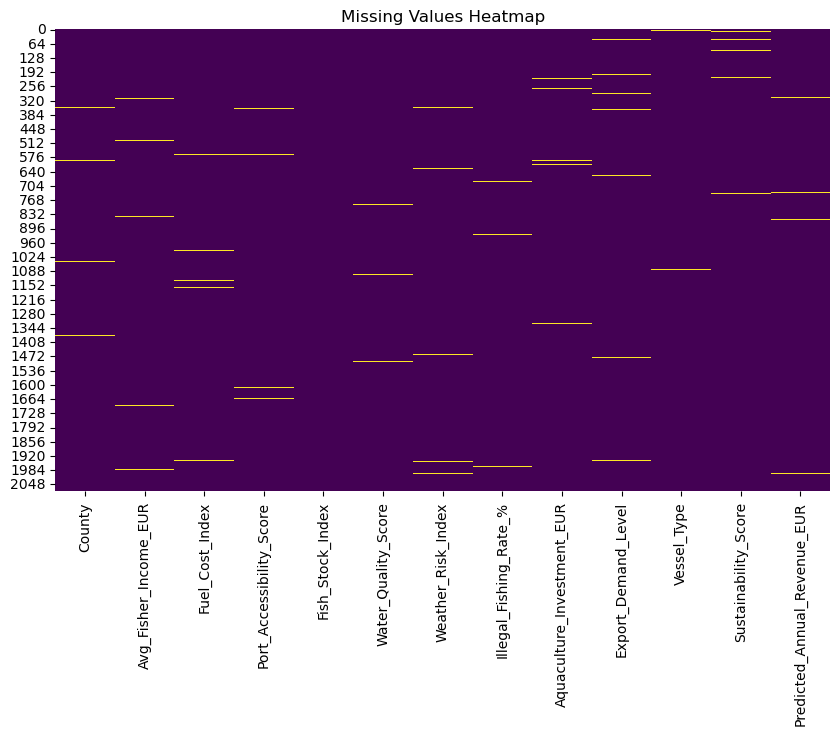

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Heatmap")

plt.show()

In [22]:
duplicates = df.duplicated().sum()

print("Number of duplicated rows:", duplicates)

Number of duplicated rows: 0


In [23]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
Index(['Avg_Fisher_Income_EUR', 'Fuel_Cost_Index', 'Port_Accessibility_Score',
       'Fish_Stock_Index', 'Water_Quality_Score', 'Weather_Risk_Index',
       'Illegal_Fishing_Rate_%', 'Aquaculture_Investment_EUR',
       'Sustainability_Score', 'Predicted_Annual_Revenue_EUR'],
      dtype='object')

Categorical columns:
Index(['County', 'Export_Demand_Level', 'Vessel_Type'], dtype='object')


The variables were separated into numerical and categorical columns because each type of variable may require a different cleaning approach for numerical variables, missing values can be replaced with a statistical measure, such as the mean or median. For categorical variables, the mode is usually applied, as it represents the most frequent category.

In [24]:
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [25]:
df.isnull().sum()

County                          0
Avg_Fisher_Income_EUR           0
Fuel_Cost_Index                 0
Port_Accessibility_Score        0
Fish_Stock_Index                0
Water_Quality_Score             0
Weather_Risk_Index              0
Illegal_Fishing_Rate_%          0
Aquaculture_Investment_EUR      0
Export_Demand_Level             0
Vessel_Type                     0
Sustainability_Score            0
Predicted_Annual_Revenue_EUR    0
dtype: int64

Missing values were filled according to the variable type. Numerical columns were filled with the median, and categorical columns were filled with the mode.

In [26]:
df.duplicated().sum()

np.int64(0)

## Data Consistency Check

The numerical columns were checked to identify possible unusual values before continuing with the analysis.

In [27]:
df.describe()

,Avg_Fisher_Income_EUR,Fuel_Cost_Index,Port_Accessibility_Score,Fish_Stock_Index,Water_Quality_Score,Weather_Risk_Index,Illegal_Fishing_Rate_%,Aquaculture_Investment_EUR,Sustainability_Score,Predicted_Annual_Revenue_EUR
count,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000
mean,72512.495885,100.090630,5.969663,5.955197,7.007192,4.114043,4.913582,109865.901082,103.045053,174694.794279
std,11785.578768,14.819598,1.970067,1.933746,1.450075,1.887078,1.992639,22113.118342,22.243771,43269.945095
min,35298.260000,52.680000,1.000000,1.000000,2.100000,1.000000,0.000000,38247.500000,25.490000,28148.810000
25%,64910.860000,90.410000,4.630000,4.650000,6.030000,2.727500,3.580000,95611.100000,88.465000,146179.925000
50%,72646.920000,100.280000,6.000000,5.940000,7.030000,4.060000,4.850000,110054.900000,103.500000,176154.600000
75%,80255.117500,109.710000,7.310000,7.250000,7.990000,5.400000,6.300000,125139.440000,117.882500,204588.972500
max,107127.470000,145.030000,10.000000,10.000000,10.000000,10.000000,11.790000,170958.000000,172.740000,303843.800000


In [28]:
score_columns = [
    'Port_Accessibility_Score',
    'Fish_Stock_Index',
    'Water_Quality_Score',
    'Weather_Risk_Index'
]

for column in score_columns:
    print(column)
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())
    print()

Port_Accessibility_Score
Minimum: 1.0
Maximum: 10.0

Fish_Stock_Index
Minimum: 1.0
Maximum: 10.0

Water_Quality_Score
Minimum: 2.1
Maximum: 10.0

Weather_Risk_Index
Minimum: 1.0
Maximum: 10.0



The score based variables were checked to confirm whether their values were within the expected ranges

## Exploratory Data Analysis

Some visualisations were created to understand the main patterns in the dataset before applying statistical analysis and machine learning.

In [29]:
df['Export_Demand_Level'].value_counts()

Export_Demand_Level
Average    998
Low        554
High       528
Name: count, dtype: int64

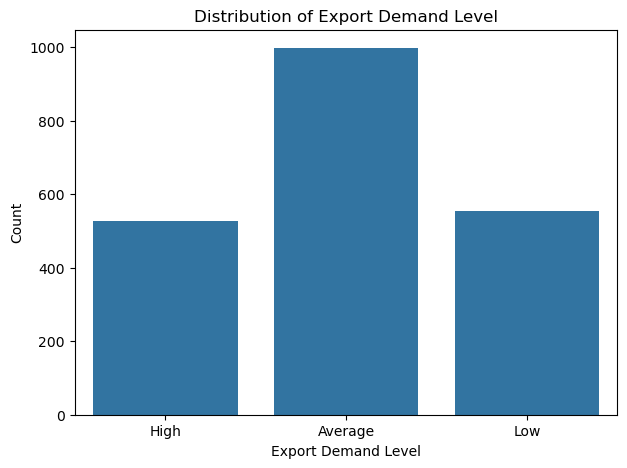

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Export_Demand_Level')

plt.title("Distribution of Export Demand Level")
plt.xlabel("Export Demand Level")
plt.ylabel("Count")

plt.show()

The export demand categories were checked to understand how the target variable for classification is distributed.

In [31]:
df['Vessel_Type'].value_counts()

Vessel_Type
Gillnetter     439
Small Boat     416
Trawler        414
Purse Seine    406
Longliner      405
Name: count, dtype: int64

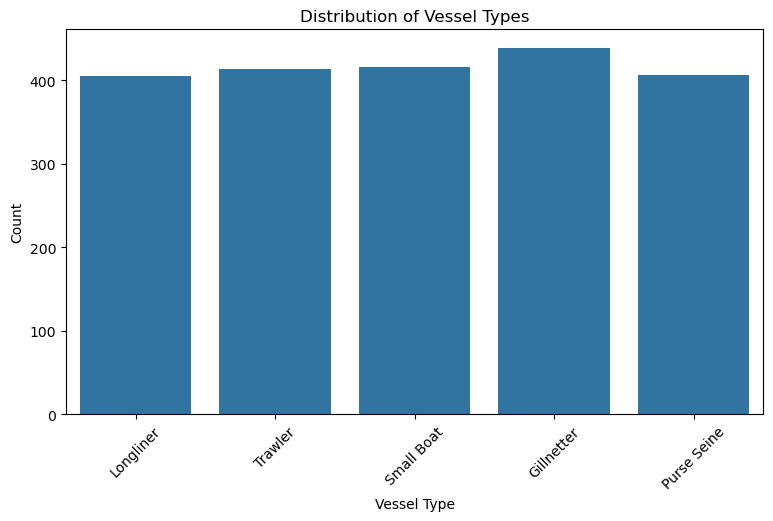

In [32]:
plt.figure(figsize=(9,5))

sns.countplot(data=df, x='Vessel_Type')

plt.title("Distribution of Vessel Types")
plt.xlabel("Vessel Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

Vessel type was explored because it is one of the operational variables that may influence fisheries performance.

The distribution of predicted annual revenue was explored to better understand the spread of the target variable used for regression analysis.

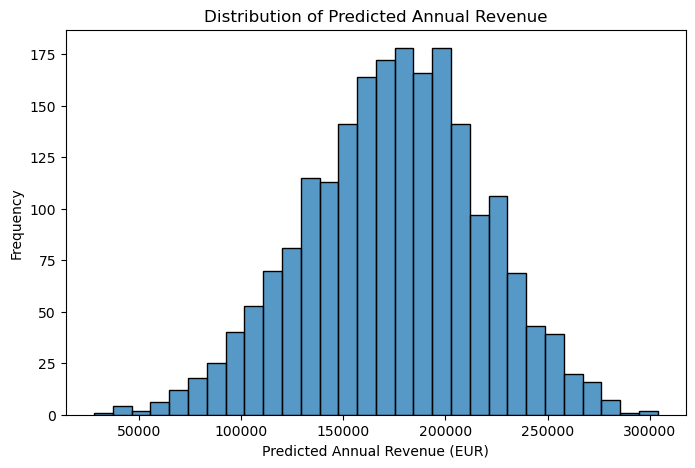

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df['Predicted_Annual_Revenue_EUR'], bins=30)

plt.title("Distribution of Predicted Annual Revenue")
plt.xlabel("Predicted Annual Revenue (EUR)")
plt.ylabel("Frequency")

plt.show()

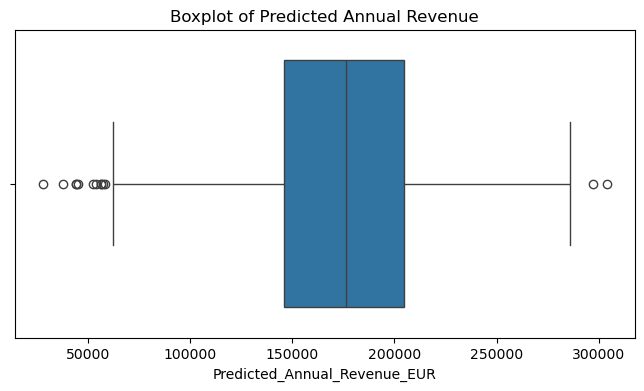

In [34]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Predicted_Annual_Revenue_EUR'])

plt.title("Boxplot of Predicted Annual Revenue")

plt.show()

The revenue distribution appears slightly spread, with some higher revenue values visible in the boxplot.

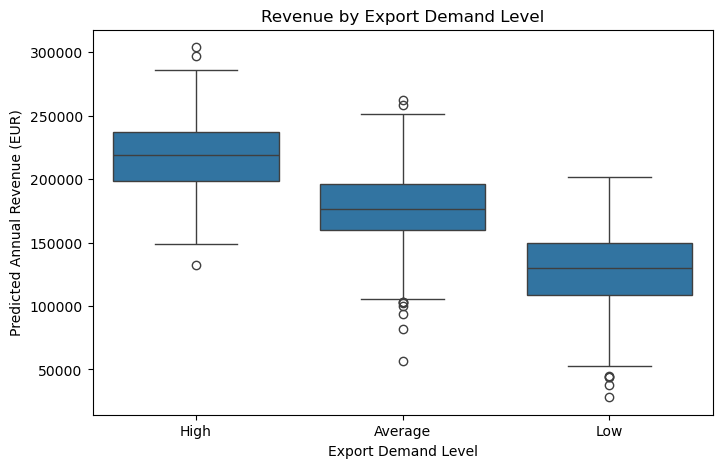

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Export_Demand_Level',
    y='Predicted_Annual_Revenue_EUR'
)

plt.title("Revenue by Export Demand Level")
plt.xlabel("Export Demand Level")
plt.ylabel("Predicted Annual Revenue (EUR)")

plt.show()

The relationship between export demand level and annual revenue was explored to identify possible differences between market demand categories.

The relationship between sustainability score and revenue was explored because sustainability is one of the key indicators in the dataset.

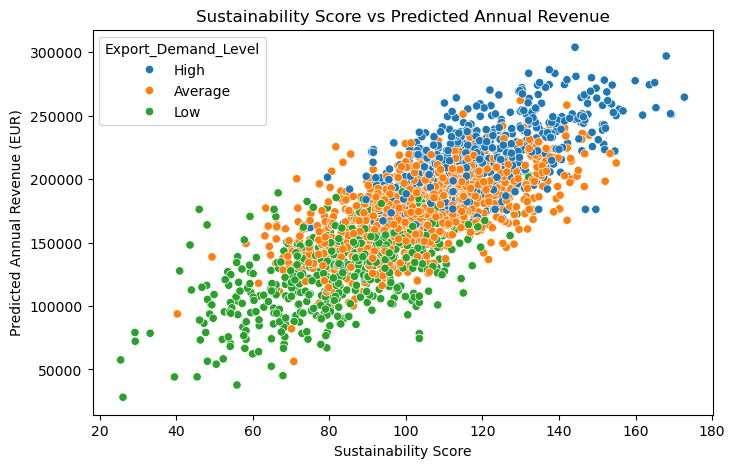

In [36]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Sustainability_Score',
    y='Predicted_Annual_Revenue_EUR',
    hue='Export_Demand_Level'
)

plt.title("Sustainability Score vs Predicted Annual Revenue")
plt.xlabel("Sustainability Score")
plt.ylabel("Predicted Annual Revenue (EUR)")

plt.show()

Fish stock availability was compared with annual revenue to explore whether higher stock levels are associated with stronger fisheries performance.

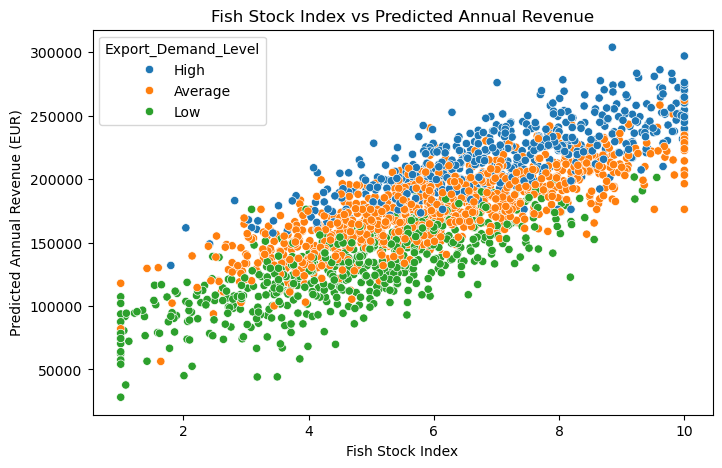

In [37]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Fish_Stock_Index',
    y='Predicted_Annual_Revenue_EUR',
    hue='Export_Demand_Level'
)

plt.title("Fish Stock Index vs Predicted Annual Revenue")
plt.xlabel("Fish Stock Index")
plt.ylabel("Predicted Annual Revenue (EUR)")

plt.show()

A correlation heatmap was used to explore relationships between numerical variables.

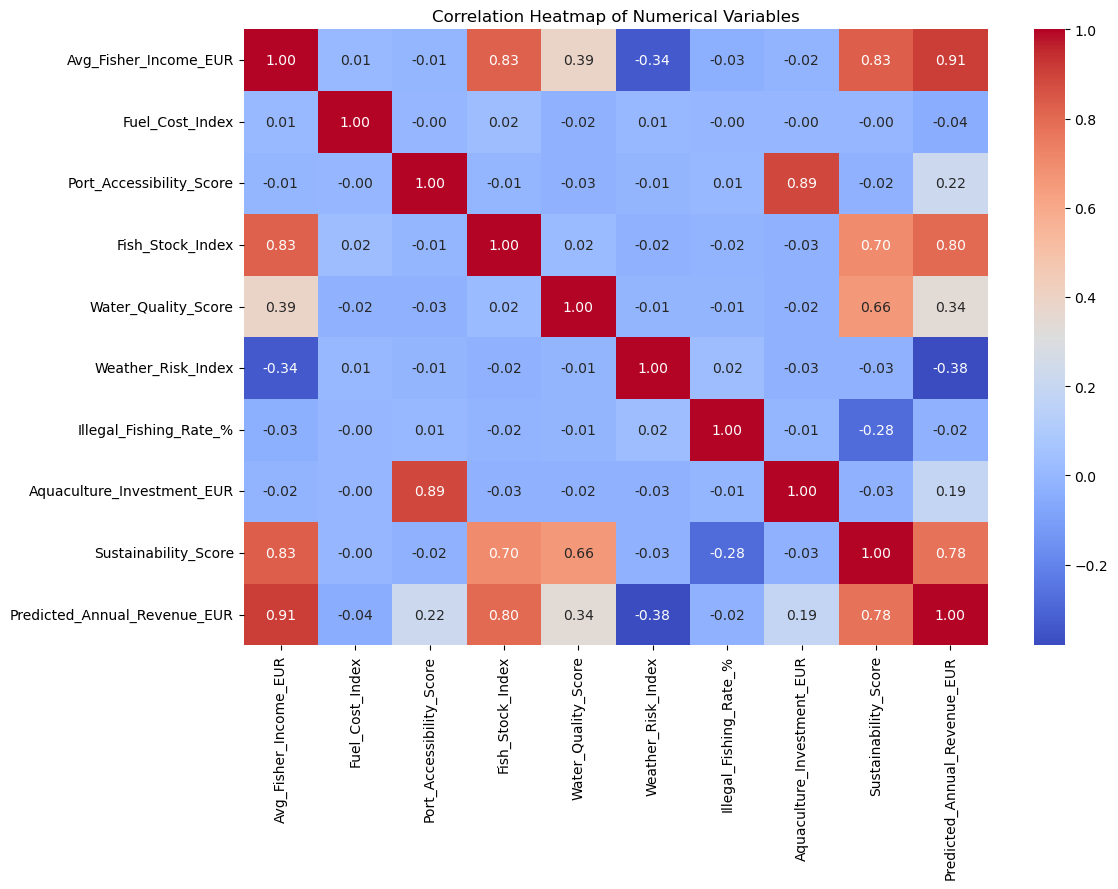

In [38]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

## Encoding, Scaling and Feature Engineering

Categorical variables were encoded and selected numerical variables were prepared for later analysis and modelling.

In [40]:
df_clean = df.copy()

In [41]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_clean['Export_Demand_Level_Encoded'] = label_encoder.fit_transform(df_clean['Export_Demand_Level'])

df_clean[['Export_Demand_Level', 'Export_Demand_Level_Encoded']].head()

,Export_Demand_Level,Export_Demand_Level_Encoded
0,High,1
1,Average,0
2,Low,2
3,Average,0
4,Average,0


Export demand level was encoded because machine learning models require numerical input.

In [43]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=['County', 'Vessel_Type'],
    drop_first=True
)

df_encoded.head()

,Avg_Fisher_Income_EUR,Fuel_Cost_Index,Port_Accessibility_Score,Fish_Stock_Index,Water_Quality_Score,Weather_Risk_Index,Illegal_Fishing_Rate_%,Aquaculture_Investment_EUR,Export_Demand_Level,Sustainability_Score,...,County_Galway,County_Kerry,County_Limerick,County_Mayo,County_Waterford,County_Wexford,Vessel_Type_Longliner,Vessel_Type_Purse Seine,Vessel_Type_Small Boat,Vessel_Type_Trawler
0,81077.05,91.19,6.95,5.10,7.10,1.23,4.12,108112.88,High,99.44,...,False,False,False,False,True,False,True,False,False,False
1,76078.84,99.09,7.51,8.20,6.16,5.38,4.06,112746.74,Average,115.02,...,False,False,False,False,False,False,False,False,False,True
2,50576.94,91.93,7.59,3.82,4.04,4.71,3.07,132088.49,Low,61.75,...,False,False,False,False,False,False,True,False,False,False
3,73236.59,109.53,6.29,7.02,7.60,5.99,5.56,109732.87,Average,115.48,...,False,False,False,False,False,False,False,False,True,False
4,69185.63,109.94,5.41,5.27,8.59,5.38,5.72,91268.62,Average,110.90,...,False,False,False,False,False,False,False,False,False,False


County and vessel type were converted into dummy variables so they could be used in later modelling stages.

In [44]:
df_encoded['Investment_per_Revenue'] = (
    df_encoded['Aquaculture_Investment_EUR'] / df_encoded['Predicted_Annual_Revenue_EUR']
)

df_encoded['Risk_Score'] = (
    df_encoded['Weather_Risk_Index'] + df_encoded['Illegal_Fishing_Rate_%']
)

Two new features were created to support the analysis: investment per revenue and an overall risk score.

Numerical variables were scaled to prepare the dataset for dimensionality reduction and machine learning models.

In [45]:
from sklearn.preprocessing import StandardScaler

features_to_scale = df_encoded.drop(
    columns=['Export_Demand_Level', 'Predicted_Annual_Revenue_EUR']
)

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features_to_scale)

df_scaled = pd.DataFrame(
    scaled_features,
    columns=features_to_scale.columns
)

df_scaled.head()

,Avg_Fisher_Income_EUR,Fuel_Cost_Index,Port_Accessibility_Score,Fish_Stock_Index,Water_Quality_Score,Weather_Risk_Index,Illegal_Fishing_Rate_%,Aquaculture_Investment_EUR,Sustainability_Score,Export_Demand_Level_Encoded,...,County_Limerick,County_Mayo,County_Waterford,County_Wexford,Vessel_Type_Longliner,Vessel_Type_Purse Seine,Vessel_Type_Small Boat,Vessel_Type_Trawler,Investment_per_Revenue,Risk_Score
0,0.726873,-0.600743,0.497736,-0.442355,0.064017,-1.528679,-0.398352,-0.079294,-0.162109,0.255028,...,-0.351734,-0.314301,3.083026,-0.330656,2.033667,-0.492476,-0.5,-0.498497,-0.539014,-1.324756
1,0.302675,-0.067537,0.782058,1.161137,-0.584381,0.671017,-0.428471,0.130309,0.538480,-0.939699,...,-0.351734,-0.314301,-0.324357,-0.330656,-0.491723,-0.492476,-0.5,2.006030,-0.459242,0.148546
2,-1.861668,-0.550797,0.822676,-1.104442,-2.046726,0.315885,-0.925419,1.005192,-1.856924,1.449755,...,-0.351734,-0.314301,-0.324357,-0.330656,2.033667,-0.492476,-0.5,-0.498497,2.163627,-0.449420
3,0.061454,0.637105,0.162641,0.550775,0.408910,0.994346,0.324481,-0.006017,0.559165,-0.939699,...,-0.351734,-0.314301,-0.324357,-0.330656,-0.491723,-0.492476,2.0,-0.498497,-0.363179,0.908611
4,-0.282351,0.664778,-0.284152,-0.354422,1.091798,0.671017,0.404796,-0.841209,0.353215,-0.939699,...,-0.351734,-0.314301,-0.324357,-0.330656,-0.491723,-0.492476,-0.5,-0.498497,-0.209359,0.746512


In [46]:
df_scaled['Export_Demand_Level_Encoded'] = df_encoded['Export_Demand_Level_Encoded'].values
df_scaled['Predicted_Annual_Revenue_EUR'] = df_encoded['Predicted_Annual_Revenue_EUR'].values

The scaled dataset was created for later use in PCA, LDA, and machine learning models.

In [47]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

## PCA vs LDA

PCA and LDA were applied to compare different dimensionality reduction techniques.

In [48]:
X = df_scaled.drop(
    columns=['Export_Demand_Level_Encoded', 'Predicted_Annual_Revenue_EUR']
)

y = df_scaled['Export_Demand_Level_Encoded']

In [49]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

In [50]:
pca_df = pd.DataFrame(
    data=X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Export_Demand_Level'] = y.values

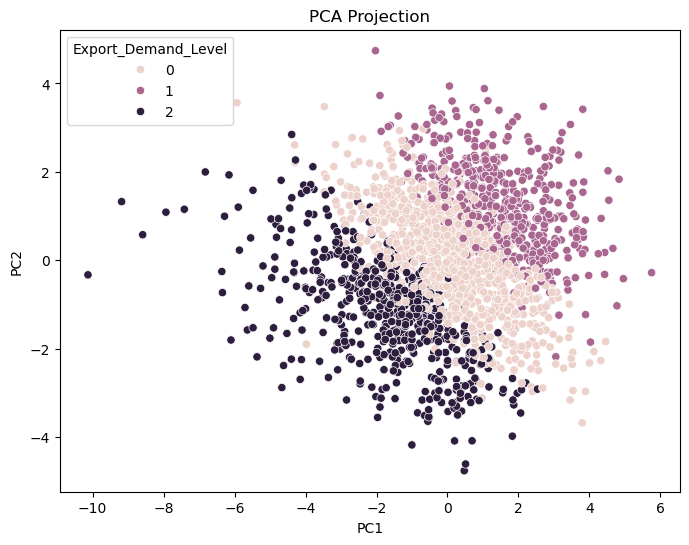

In [51]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Export_Demand_Level'
)

plt.title("PCA Projection")

plt.show()

PCA was used to reduce the dimensionality of the dataset while preserving as much variation as possible

In [52]:
lda = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda.fit_transform(X, y)

In [53]:
lda_df = pd.DataFrame(
    data=X_lda,
    columns=['LD1', 'LD2']
)

lda_df['Export_Demand_Level'] = y.values

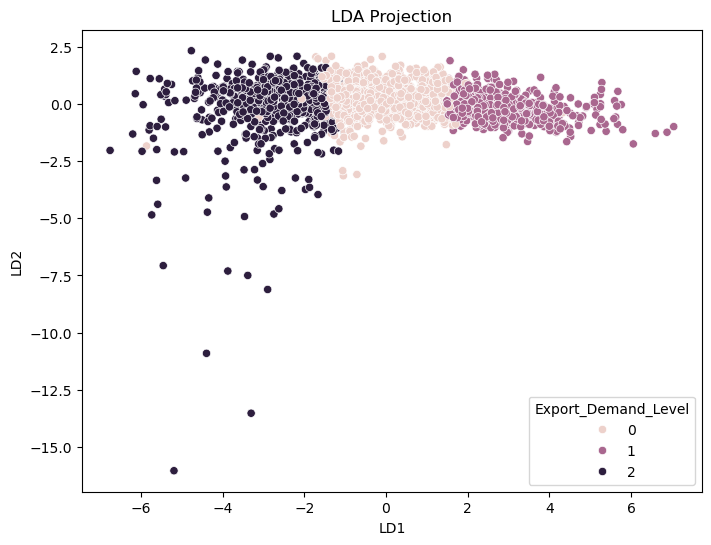

In [54]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=lda_df,
    x='LD1',
    y='LD2',
    hue='Export_Demand_Level'
)

plt.title("LDA Projection")

plt.show()

LDA was applied to explore how well the export demand classes could be separated using supervised dimensionality reduction.

# Part 2 — Statistical Techniques for Data Analytics

## Descriptive Statistics

Descriptive statistics were used to summarise the main numerical variables in the dataset

In [55]:
from scipy import stats
from scipy.stats import norm

In [56]:
df[numerical_columns].describe()

,Avg_Fisher_Income_EUR,Fuel_Cost_Index,Port_Accessibility_Score,Fish_Stock_Index,Water_Quality_Score,Weather_Risk_Index,Illegal_Fishing_Rate_%,Aquaculture_Investment_EUR,Sustainability_Score,Predicted_Annual_Revenue_EUR
count,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000
mean,72512.495885,100.090630,5.969663,5.955197,7.007192,4.114043,4.913582,109865.901082,103.045053,174694.794279
std,11785.578768,14.819598,1.970067,1.933746,1.450075,1.887078,1.992639,22113.118342,22.243771,43269.945095
min,35298.260000,52.680000,1.000000,1.000000,2.100000,1.000000,0.000000,38247.500000,25.490000,28148.810000
25%,64910.860000,90.410000,4.630000,4.650000,6.030000,2.727500,3.580000,95611.100000,88.465000,146179.925000
50%,72646.920000,100.280000,6.000000,5.940000,7.030000,4.060000,4.850000,110054.900000,103.500000,176154.600000
75%,80255.117500,109.710000,7.310000,7.250000,7.990000,5.400000,6.300000,125139.440000,117.882500,204588.972500
max,107127.470000,145.030000,10.000000,10.000000,10.000000,10.000000,11.790000,170958.000000,172.740000,303843.800000


In [57]:
descriptive_stats = df[numerical_columns].agg(['mean', 'median', 'std', 'var', 'min', 'max'])

descriptive_stats

,Avg_Fisher_Income_EUR,Fuel_Cost_Index,Port_Accessibility_Score,Fish_Stock_Index,Water_Quality_Score,Weather_Risk_Index,Illegal_Fishing_Rate_%,Aquaculture_Investment_EUR,Sustainability_Score,Predicted_Annual_Revenue_EUR
mean,7.251250e+04,100.090630,5.969663,5.955197,7.007192,4.114043,4.913582,1.098659e+05,103.045053,1.746948e+05
median,7.264692e+04,100.280000,6.000000,5.940000,7.030000,4.060000,4.850000,1.100549e+05,103.500000,1.761546e+05
std,1.178558e+04,14.819598,1.970067,1.933746,1.450075,1.887078,1.992639,2.211312e+04,22.243771,4.326995e+04
var,1.388999e+08,219.620478,3.881163,3.739372,2.102716,3.561062,3.970610,4.889900e+08,494.785341,1.872288e+09
min,3.529826e+04,52.680000,1.000000,1.000000,2.100000,1.000000,0.000000,3.824750e+04,25.490000,2.814881e+04
max,1.071275e+05,145.030000,10.000000,10.000000,10.000000,10.000000,11.790000,1.709580e+05,172.740000,3.038438e+05


The descriptive statistics provide an overview of the central tendency, variation, and range of the numerical variables.

## Normality Test

A Shapiro-Wilk test was applied to check whether predicted annual revenue follows a normal distribution.

In [58]:
statistic, p_value = stats.shapiro(df['Predicted_Annual_Revenue_EUR'])

print("Shapiro-Wilk Statistic:", statistic)
print("p-value:", p_value)

Shapiro-Wilk Statistic: 0.997763758022208
p-value: 0.0050042447819688834


In [59]:
if p_value > 0.05:
    print("The data appears to be normally distributed.")
else:
    print("The data does not appear to be normally distributed.")

The data does not appear to be normally distributed.


The normality test result was used to support the choice and interpretation of later statistical tests

## Statistical Visualisations

Three statistical visualisations were created to support the descriptive analysis

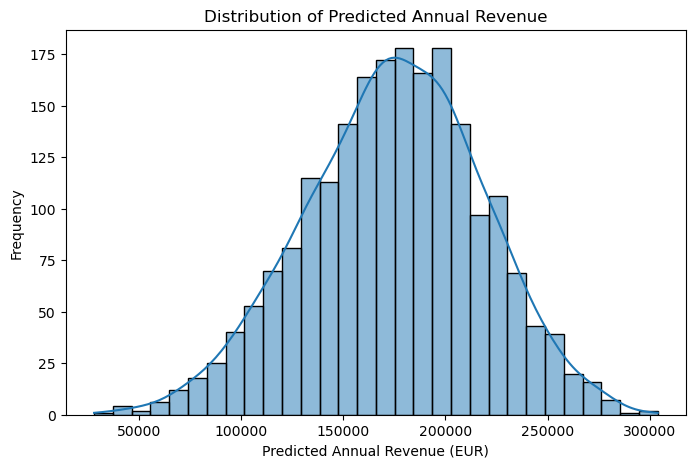

In [61]:
plt.figure(figsize=(8,5))

sns.histplot(df['Predicted_Annual_Revenue_EUR'], bins=30, kde=True)

plt.title("Distribution of Predicted Annual Revenue")
plt.xlabel("Predicted Annual Revenue (EUR)")
plt.ylabel("Frequency")

plt.show()

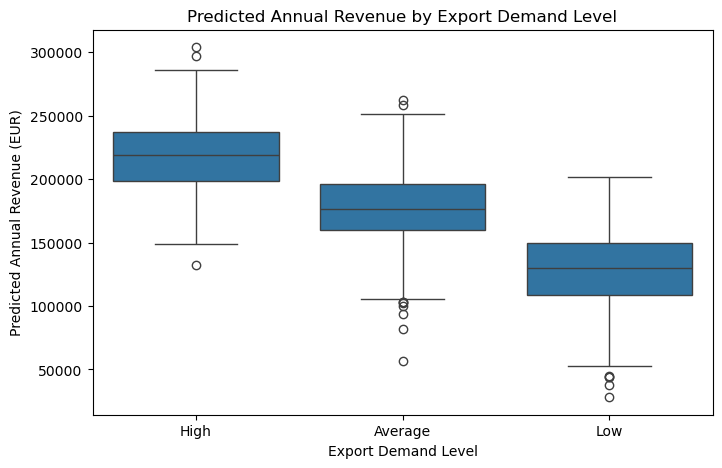

In [62]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Export_Demand_Level',
    y='Predicted_Annual_Revenue_EUR'
)

plt.title("Predicted Annual Revenue by Export Demand Level")
plt.xlabel("Export Demand Level")
plt.ylabel("Predicted Annual Revenue (EUR)")

plt.show()

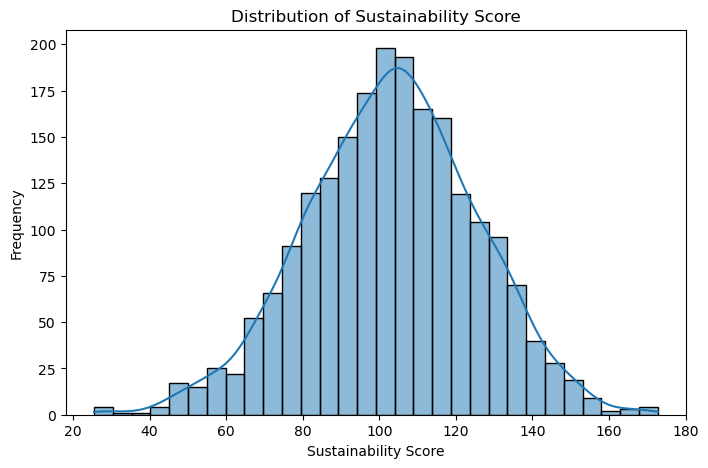

In [63]:
plt.figure(figsize=(8,5))

sns.histplot(df['Sustainability_Score'], bins=30, kde=True)

plt.title("Distribution of Sustainability Score")
plt.xlabel("Sustainability Score")
plt.ylabel("Frequency")

plt.show()

The visualisations show the distribution of key numerical variables and the variation in revenue across export demand categories.

## Confidence Intervals

Confidence intervals were calculated to compare the average predicted annual revenue between low and high export demand groups.

In [64]:
high_demand_revenue = df[df['Export_Demand_Level'] == 'High']['Predicted_Annual_Revenue_EUR']
low_demand_revenue = df[df['Export_Demand_Level'] == 'Low']['Predicted_Annual_Revenue_EUR']

In [65]:
def confidence_interval(data, confidence=0.95):
    mean = np.mean(data)
    standard_error = stats.sem(data)
    interval = stats.t.interval(
        confidence,
        len(data)-1,
        loc=mean,
        scale=standard_error
    )
    return mean, interval

In [66]:
high_mean, high_ci = confidence_interval(high_demand_revenue)
low_mean, low_ci = confidence_interval(low_demand_revenue)

print("High Demand Mean Revenue:", high_mean)
print("High Demand 95% Confidence Interval:", high_ci)

print("\nLow Demand Mean Revenue:", low_mean)
print("Low Demand 95% Confidence Interval:", low_ci)

High Demand Mean Revenue: 218692.32339015152
High Demand 95% Confidence Interval: (np.float64(216317.0845688295), np.float64(221067.56221147353))

Low Demand Mean Revenue: 128355.8544404332
Low Demand 95% Confidence Interval: (np.float64(125823.35194381716), np.float64(130888.35693704925))


The confidence intervals provide an estimated range for the average predicted annual revenue in the high and low export demand groups.

## Hypothesis Testing

Three hypothesis tests were conducted to explore relationships between key variables in the dataset.

### Test 1: Revenue Difference Between High and Low Export Demand

H0: There is no significant difference in predicted annual revenue between high and low export demand groups.

H1: There is a significant difference in predicted annual revenue between high and low export demand groups.

In [68]:
t_stat, p_value = stats.ttest_ind(
    high_demand_revenue,
    low_demand_revenue,
    equal_var=False
)

print("T-statistic:", t_stat)
print("p-value:", p_value)

T-statistic: 51.10874650593193
p-value: 2.3852563498152193e-290


In [69]:
if p_value < 0.05:
    print("Reject H0: There is a significant difference between the groups.")
else:
    print("Fail to reject H0: There is no significant difference between the groups.")

Reject H0: There is a significant difference between the groups.


### Test 2: Revenue Difference Across Vessel Types

H0: The average predicted annual revenue is the same across vessel types.

H1: At least one vessel type has a different average predicted annual revenue.

In [70]:
trawler_revenue = df[df['Vessel_Type'] == 'Trawler']['Predicted_Annual_Revenue_EUR']
longliner_revenue = df[df['Vessel_Type'] == 'Longliner']['Predicted_Annual_Revenue_EUR']
gillnetter_revenue = df[df['Vessel_Type'] == 'Gillnetter']['Predicted_Annual_Revenue_EUR']
purse_seine_revenue = df[df['Vessel_Type'] == 'Purse Seine']['Predicted_Annual_Revenue_EUR']
small_boat_revenue = df[df['Vessel_Type'] == 'Small Boat']['Predicted_Annual_Revenue_EUR']

In [71]:
f_stat, p_value = stats.f_oneway(
    trawler_revenue,
    longliner_revenue,
    gillnetter_revenue,
    purse_seine_revenue,
    small_boat_revenue
)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 2.3878015060731417
p-value: 0.04905570930159938


In [72]:
if p_value < 0.05:
    print("Reject H0: At least one vessel type has a different average revenue.")
else:
    print("Fail to reject H0: No significant revenue difference was found across vessel types.")

Reject H0: At least one vessel type has a different average revenue.


### Test 3: Sustainability Score Difference Across Export Demand Levels

H0: The average sustainability score is the same across export demand levels.

H1: At least one export demand level has a different average sustainability score.

In [73]:
low_sustainability = df[df['Export_Demand_Level'] == 'Low']['Sustainability_Score']
average_sustainability = df[df['Export_Demand_Level'] == 'Average']['Sustainability_Score']
high_sustainability = df[df['Export_Demand_Level'] == 'High']['Sustainability_Score']

In [74]:
f_stat, p_value = stats.f_oneway(
    low_sustainability,
    average_sustainability,
    high_sustainability
)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 622.8825183404024
p-value: 1.2034659393792394e-212


In [75]:
if p_value < 0.05:
    print("Reject H0: At least one export demand group has a different average sustainability score.")
else:
    print("Fail to reject H0: No significant sustainability difference was found across export demand groups.")

Reject H0: At least one export demand group has a different average sustainability score.


## Correlation Analysis

Correlation analysis was used to identify relationships between numerical variables and the predicted annual revenue.

In [76]:
correlation_with_revenue = df[numerical_columns].corr()['Predicted_Annual_Revenue_EUR'].sort_values(ascending=False)

correlation_with_revenue

Predicted_Annual_Revenue_EUR    1.000000
Avg_Fisher_Income_EUR           0.912879
Fish_Stock_Index                0.802141
Sustainability_Score            0.777141
Water_Quality_Score             0.337205
Port_Accessibility_Score        0.220833
Aquaculture_Investment_EUR      0.189424
Illegal_Fishing_Rate_%         -0.022891
Fuel_Cost_Index                -0.042230
Weather_Risk_Index             -0.381313
Name: Predicted_Annual_Revenue_EUR, dtype: float64

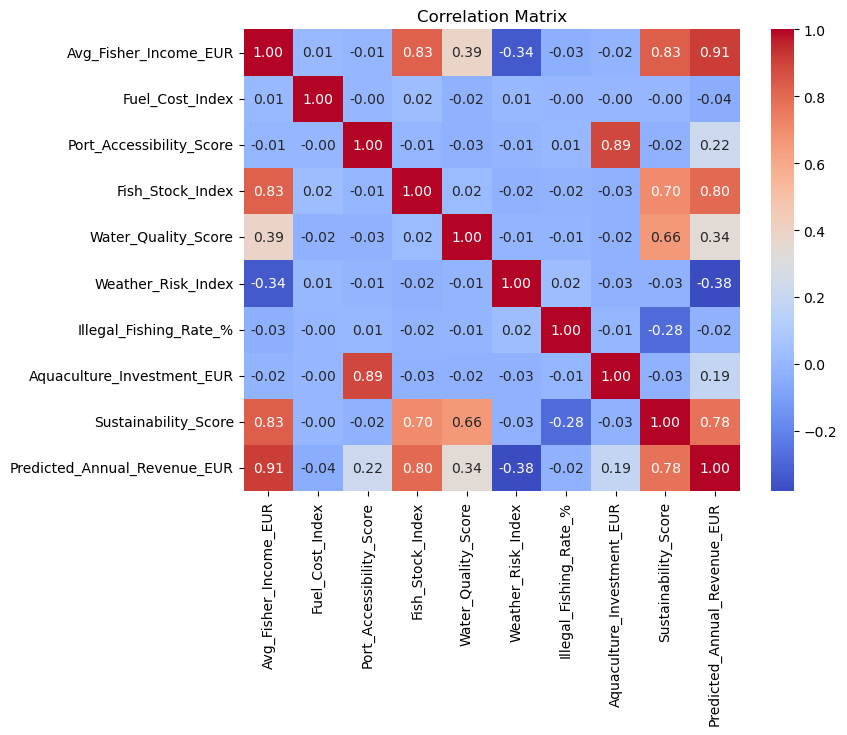

In [77]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

The correlation matrix helps identify which numerical variables have stronger positive or negative relationships with predicted annual revenue.

## Linear Regression

A linear regression model was used to explore how selected numerical variables relate to predicted annual revenue.

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [79]:
X = df[[
    'Avg_Fisher_Income_EUR',
    'Fuel_Cost_Index',
    'Port_Accessibility_Score',
    'Fish_Stock_Index',
    'Water_Quality_Score',
    'Weather_Risk_Index',
    'Illegal_Fishing_Rate_%',
    'Aquaculture_Investment_EUR',
    'Sustainability_Score'
]]

y = df['Predicted_Annual_Revenue_EUR']

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [81]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [82]:
y_pred = linear_model.predict(X_test)

In [83]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 8503.840670553525
Mean Squared Error: 116261434.51441185
R2 Score: 0.9390046090150748


The linear regression model was evaluated using MAE, MSE, and R2 score to understand how well the selected numerical variables explain predicted annual revenue.

# Part 3 — Machine Learning

Machine learning models were applied to predict annual fisheries revenue and classify export demand levels. Both regression and classification tasks were included because the dataset contains one numerical target and one categorical target.

## Machine Learning Approach

This project uses supervised learning because the dataset includes defined target variables. Regression is used for predicting annual revenue, while classification is used for predicting export demand level.

## Regression Models

In [85]:
df_encoded.columns

Index(['Avg_Fisher_Income_EUR', 'Fuel_Cost_Index', 'Port_Accessibility_Score',
       'Fish_Stock_Index', 'Water_Quality_Score', 'Weather_Risk_Index',
       'Illegal_Fishing_Rate_%', 'Aquaculture_Investment_EUR',
       'Export_Demand_Level', 'Sustainability_Score',
       'Predicted_Annual_Revenue_EUR', 'Export_Demand_Level_Encoded',
       'County_Cork', 'County_Donegal', 'County_Dublin', 'County_Galway',
       'County_Kerry', 'County_Limerick', 'County_Mayo', 'County_Waterford',
       'County_Wexford', 'Vessel_Type_Longliner', 'Vessel_Type_Purse Seine',
       'Vessel_Type_Small Boat', 'Vessel_Type_Trawler',
       'Investment_per_Revenue', 'Risk_Score'],
      dtype='object')

In [86]:
X_regression = df_encoded.drop(
    columns=[
        'Predicted_Annual_Revenue_EUR',
        'Export_Demand_Level',
        'Export_Demand_Level_Encoded'
    ],
    errors='ignore'
)

y_regression = df_encoded['Predicted_Annual_Revenue_EUR']

In [87]:
X_regression.head()

,Avg_Fisher_Income_EUR,Fuel_Cost_Index,Port_Accessibility_Score,Fish_Stock_Index,Water_Quality_Score,Weather_Risk_Index,Illegal_Fishing_Rate_%,Aquaculture_Investment_EUR,Sustainability_Score,County_Cork,...,County_Limerick,County_Mayo,County_Waterford,County_Wexford,Vessel_Type_Longliner,Vessel_Type_Purse Seine,Vessel_Type_Small Boat,Vessel_Type_Trawler,Investment_per_Revenue,Risk_Score
0,81077.05,91.19,6.95,5.10,7.10,1.23,4.12,108112.88,99.44,False,...,False,False,True,False,True,False,False,False,0.536553,5.35
1,76078.84,99.09,7.51,8.20,6.16,5.38,4.06,112746.74,115.02,False,...,False,False,False,False,False,False,False,True,0.556817,9.44
2,50576.94,91.93,7.59,3.82,4.04,4.71,3.07,132088.49,61.75,True,...,False,False,False,False,True,False,False,False,1.223076,7.78
3,73236.59,109.53,6.29,7.02,7.60,5.99,5.56,109732.87,115.48,False,...,False,False,False,False,False,False,True,False,0.581218,11.55
4,69185.63,109.94,5.41,5.27,8.59,5.38,5.72,91268.62,110.90,False,...,False,False,False,False,False,False,False,False,0.620292,11.10


In [88]:
y_regression.head()

0    201495.28
1    202484.46
2    107997.00
3    188797.98
4    147138.23
Name: Predicted_Annual_Revenue_EUR, dtype: float64

In [89]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression,
    y_regression,
    test_size=0.2,
    random_state=42
)

In [90]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [91]:
linear_regression_model = LinearRegression()

linear_regression_model.fit(X_train_reg, y_train_reg)

linear_regression_predictions = linear_regression_model.predict(X_test_reg)

In [92]:
print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test_reg, linear_regression_predictions))
print("MSE:", mean_squared_error(y_test_reg, linear_regression_predictions))
print("R2 Score:", r2_score(y_test_reg, linear_regression_predictions))

Linear Regression Results
MAE: 7612.442673875272
MSE: 104185495.06129305
R2 Score: 0.9453401290568644


In [93]:
decision_tree_regressor = DecisionTreeRegressor(random_state=42)

decision_tree_regressor.fit(X_train_reg, y_train_reg)

decision_tree_predictions = decision_tree_regressor.predict(X_test_reg)

In [94]:
print("Decision Tree Regressor Results")
print("MAE:", mean_absolute_error(y_test_reg, decision_tree_predictions))
print("MSE:", mean_squared_error(y_test_reg, decision_tree_predictions))
print("R2 Score:", r2_score(y_test_reg, decision_tree_predictions))

Decision Tree Regressor Results
MAE: 10004.364903846154
MSE: 225024004.6809216
R2 Score: 0.8819434217044255


In [95]:
random_forest_regressor = RandomForestRegressor(random_state=42)

random_forest_regressor.fit(X_train_reg, y_train_reg)

random_forest_predictions = random_forest_regressor.predict(X_test_reg)

In [96]:
print("Random Forest Regressor Results")
print("MAE:", mean_absolute_error(y_test_reg, random_forest_predictions))
print("MSE:", mean_squared_error(y_test_reg, random_forest_predictions))
print("R2 Score:", r2_score(y_test_reg, random_forest_predictions))

Random Forest Regressor Results
MAE: 6916.851647596148
MSE: 88073634.95009679
R2 Score: 0.9537930542343446


In [97]:
regression_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree Regressor',
        'Random Forest Regressor'
    ],
    'MAE': [
        mean_absolute_error(y_test_reg, linear_regression_predictions),
        mean_absolute_error(y_test_reg, decision_tree_predictions),
        mean_absolute_error(y_test_reg, random_forest_predictions)
    ],
    'MSE': [
        mean_squared_error(y_test_reg, linear_regression_predictions),
        mean_squared_error(y_test_reg, decision_tree_predictions),
        mean_squared_error(y_test_reg, random_forest_predictions)
    ],
    'R2 Score': [
        r2_score(y_test_reg, linear_regression_predictions),
        r2_score(y_test_reg, decision_tree_predictions),
        r2_score(y_test_reg, random_forest_predictions)
    ]
})

regression_results

,Model,MAE,MSE,R2 Score
0,Linear Regression,7612.442674,1.041855e+08,0.945340
1,Decision Tree Regressor,10004.364904,2.250240e+08,0.881943
2,Random Forest Regressor,6916.851648,8.807363e+07,0.953793


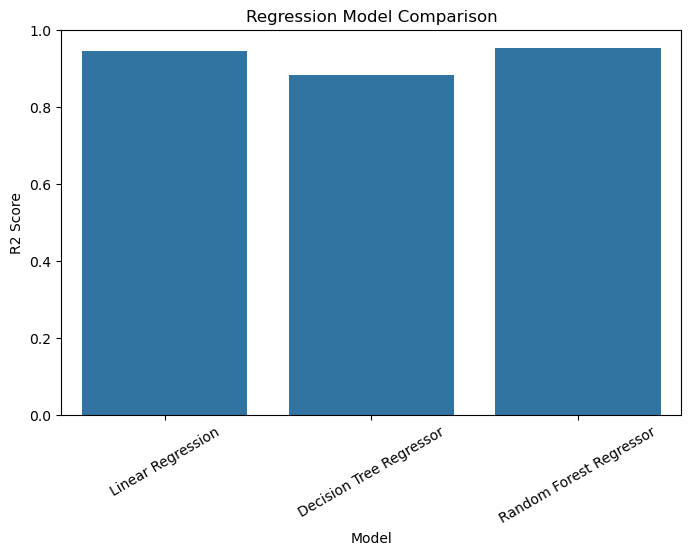

In [98]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=regression_results,
    x='Model',
    y='R2 Score'
)

plt.title("Regression Model Comparison")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)

plt.show()

The regression models were compared using MAE, MSE, and R2 score. This comparison helps identify which model performed better for predicting annual fisheries revenue.

## Classification Models

Classification models were used to predict export demand level using the available economic, environmental, operational, and sustainability indicators.

In [99]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [100]:
X_classification = df_encoded.drop(
    columns=[
        'Export_Demand_Level',
        'Export_Demand_Level_Encoded',
        'Predicted_Annual_Revenue_EUR'
    ],
    errors='ignore'
)

y_classification = df_encoded['Export_Demand_Level_Encoded']

In [101]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_classification,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

In [104]:
from sklearn.preprocessing import StandardScaler

In [105]:
scaler = StandardScaler()

X_train_class_scaled = scaler.fit_transform(X_train_class)
X_test_class_scaled = scaler.transform(X_test_class)

In [106]:
logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

logistic_model.fit(X_train_class_scaled, y_train_class)

logistic_predictions = logistic_model.predict(X_test_class_scaled)

In [107]:
print("Logistic Regression Accuracy:", accuracy_score(y_test_class, logistic_predictions))
print(classification_report(y_test_class, logistic_predictions))

Logistic Regression Accuracy: 0.9615384615384616
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       200
           1       0.95      0.97      0.96       105
           2       0.98      0.95      0.96       111

    accuracy                           0.96       416
   macro avg       0.96      0.96      0.96       416
weighted avg       0.96      0.96      0.96       416



In [108]:
decision_tree_classifier = DecisionTreeClassifier(random_state=42)

decision_tree_classifier.fit(X_train_class, y_train_class)

decision_tree_class_predictions = decision_tree_classifier.predict(X_test_class)

In [109]:
print("Decision Tree Accuracy:", accuracy_score(y_test_class, decision_tree_class_predictions))
print(classification_report(y_test_class, decision_tree_class_predictions))

Decision Tree Accuracy: 0.7860576923076923
              precision    recall  f1-score   support

           0       0.80      0.75      0.77       200
           1       0.77      0.84      0.80       105
           2       0.79      0.80      0.79       111

    accuracy                           0.79       416
   macro avg       0.78      0.80      0.79       416
weighted avg       0.79      0.79      0.79       416



In [110]:
random_forest_classifier = RandomForestClassifier(random_state=42)

random_forest_classifier.fit(X_train_class, y_train_class)

random_forest_class_predictions = random_forest_classifier.predict(X_test_class)

In [111]:
print("Random Forest Accuracy:", accuracy_score(y_test_class, random_forest_class_predictions))
print(classification_report(y_test_class, random_forest_class_predictions))

Random Forest Accuracy: 0.8942307692307693
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       200
           1       0.89      0.90      0.89       105
           2       0.93      0.87      0.90       111

    accuracy                           0.89       416
   macro avg       0.90      0.89      0.89       416
weighted avg       0.90      0.89      0.89       416



In [112]:
classification_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree Classifier',
        'Random Forest Classifier'
    ],
    'Accuracy': [
        accuracy_score(y_test_class, logistic_predictions),
        accuracy_score(y_test_class, decision_tree_class_predictions),
        accuracy_score(y_test_class, random_forest_class_predictions)
    ]
})

classification_results

,Model,Accuracy
0,Logistic Regression,0.961538
1,Decision Tree Classifier,0.786058
2,Random Forest Classifier,0.894231


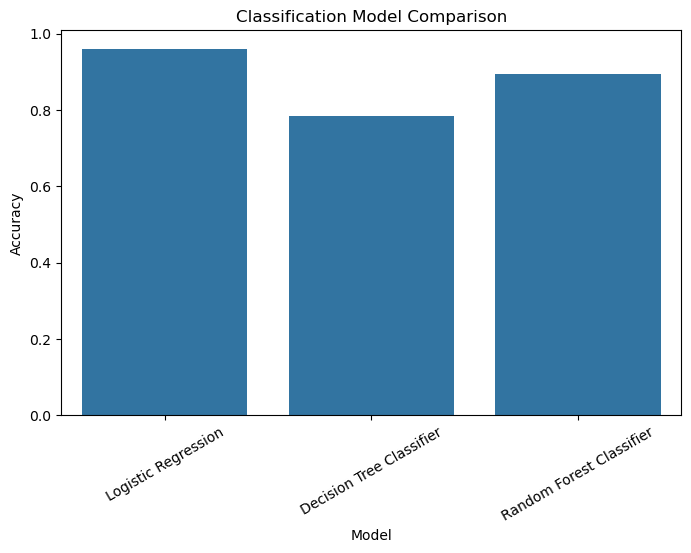

In [113]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=classification_results,
    x='Model',
    y='Accuracy'
)

plt.title("Classification Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

plt.show()

The classification models were compared using accuracy to evaluate how well they predicted export demand level.